In [7]:
import pandas as pd
import numpy as np

In [8]:
import matplotlib.pyplot as plt

In [9]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------------------- ---- 1.6/1.8 MB 96.7 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 18.6 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
a=100

In [3]:
print(a)

100


In [3]:
print(a)

100


In [5]:
import matplotlib.pyplot as plt

In [6]:
from statsmodels.stats.proportion import proportions_ztests

ImportError: cannot import name 'proportions_ztests' from 'statsmodels.stats.proportion' (C:\Users\A4047126\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\proportion.py)

In [3]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------  9.4/9.5 MB 85.1 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 41.3 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------  36.4/36.5 MB 182.8 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 182.8 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 182.8 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 46.1 MB/s  0:00:00

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   --------------------------------

In [4]:
from statsmodels.stats.proportion import proportions_ztests

ImportError: cannot import name 'proportions_ztests' from 'statsmodels.stats.proportion' (C:\Users\A4047126\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\proportion.py)

In [2]:
import matplotlib.pyplot as plt

In [10]:
import seaborn as sns

In [4]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [11]:
df=pd.read_csv(r'C:\Users\A4047126\OneDrive - Astellas Pharma Inc\Consent tracking\marketing_AB.csv')

In [10]:
import pandas as pd

In [20]:
df.tail()

,Unnamed: 0,user id,group,conversion,total ads,most ads day,most ads hour
588096,588096,1278437,ad,0,1,Tuesday,23
588097,588097,1327975,ad,0,1,Tuesday,23
588098,588098,1038442,ad,0,3,Tuesday,23
588099,588099,1496395,ad,0,1,Tuesday,23
588100,588100,1237779,ad,0,1,Tuesday,23


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [15]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [16]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [18]:
df.rename(columns={'test group':'group','converted':'conversion'},inplace=True)

In [19]:
df['conversion']=df['conversion'].astype(int)

In [21]:
df['group'].value_counts()

group
ad     564577
psa     23524
Name: count, dtype: int64

In [22]:
conversion_rates=df.groupby('group')['conversion'].mean()

In [24]:
print(conversion_rates*100)

group
ad     2.554656
psa    1.785411
Name: conversion, dtype: float64


In [26]:
summary=df.groupby('group').agg(users=('user id','count'),conversions=('conversion','sum'),conversion_rates=('conversion','mean'))

In [27]:
print(summary)

        users  conversions  conversion_rates
group                                       
ad     564577        14423          0.025547
psa     23524          420          0.017854


Text(0, 0.5, 'Conversion Rate')

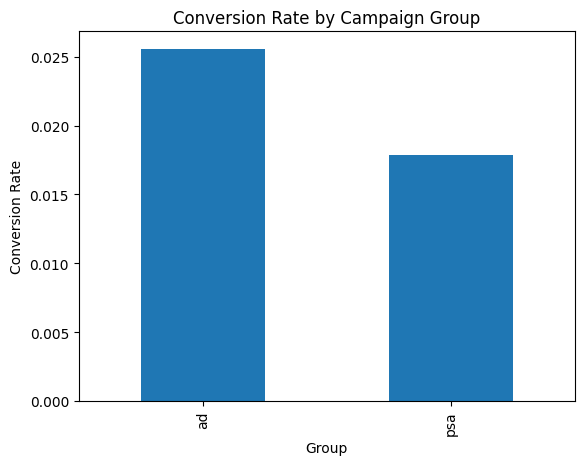

In [36]:
plt.figure()
conversion_rates.plot(kind='bar')
plt.title('Conversion Rate by Campaign Group')
plt.xlabel('Group')
plt.ylabel('Conversion Rate')

In [39]:
contigency_table=pd.crosstab(df['group'],df['conversion'])
print(contigency_table)

conversion       0      1
group                    
ad          550154  14423
psa          23104    420


In [43]:
chi2, p_value, dof, expected= stats.chi2_contingency(contigency_table)

In [41]:
from scipy import stats

In [47]:
alpha=0.05

if p_value<alpha:
    print("Statistically significant difference")
else :
    print("No significant difference")

Statistically significant difference


In [48]:
lift= (rate_A-rate_B)/rate_B *100

NameError: name 'rate_A' is not defined